# Klasifikasi Penyakit Ayam — HealthyHen
### Final Project — Computer Vision

**Deskripsi:**  
Notebook ini membangun dan membandingkan tiga pendekatan klasifikasi penyakit ayam:
1. **KNN** (K-Nearest Neighbors)
2. **SVM** (Support Vector Machine)
3. **Transfer Learning (EfficientNetV2S)**

**Dataset:** Poultry Diseases (Kaggle)  
**Kelas:** Coccidiosis | Healthy | New Castle Disease | Salmonella

---
## 1. Instalasi dan Import Library

In [1]:
!pip install kagglehub -q

In [2]:
import os, random, shutil
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


---
## 2. Download Dataset dari Kaggle

In [3]:
path = kagglehub.dataset_download("chandrashekarnatesh/poultry-diseases")
print("Dataset path:", path)

Using Colab cache for faster access to the 'poultry-diseases' dataset.
Dataset path: /kaggle/input/poultry-diseases


In [4]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'{indent}  ({len(files)} files)')

poultry-diseases/
  data/
    data/
      (0 files)


---
## 3. Sampling Data

Dataset asli berisi ~500k gambar. Kami mengambil sample per kelas untuk efisiensi training.

In [5]:
BASE_PATH   = os.path.join(path, 'data', 'data')
SAMPLE_PATH = '/content/sample_data'
SAMPLES     = {'train': 300, 'val': 40, 'test': 40} # down from 3000, 400, 400 for even more accuracy

def sample_images(src_dir, dst_dir, samples_per_class, seed=42):
    random.seed(seed)
    for class_name in sorted(os.listdir(src_dir)):
        class_path = os.path.join(src_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        images  = os.listdir(class_path)
        sampled = random.sample(images, min(samples_per_class, len(images)))
        dst_class = os.path.join(dst_dir, class_name)
        os.makedirs(dst_class, exist_ok=True)
        for img in sampled:
            shutil.copyfile(os.path.join(class_path, img), os.path.join(dst_class, img))
        print(f'  {class_name}: {len(sampled)} gambar')

for split, n in SAMPLES.items():
    print(f'\n[{split.upper()}] sampling {n}/kelas...')
    sample_images(os.path.join(BASE_PATH, split), os.path.join(SAMPLE_PATH, split), n)
print('\nSampling selesai!')


[TRAIN] sampling 300/kelas...
  Coccidiosis: 300 gambar
  Healthy: 300 gambar
  New Castle Disease: 300 gambar
  Salmonella: 300 gambar

[VAL] sampling 40/kelas...
  Coccidiosis: 40 gambar
  Healthy: 40 gambar
  New Castle Disease: 40 gambar
  Salmonella: 40 gambar

[TEST] sampling 40/kelas...
  Coccidiosis: 40 gambar
  Healthy: 40 gambar
  New Castle Disease: 40 gambar
  Salmonella: 40 gambar

Sampling selesai!


---
## 4. Eksplorasi Data (EDA)

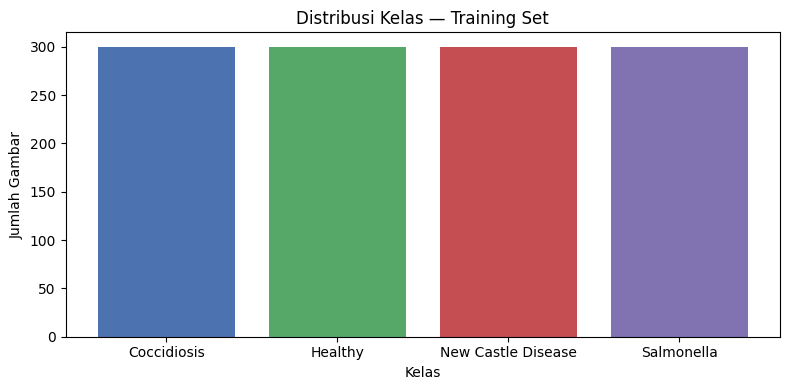

Distribusi: {'Coccidiosis': 300, 'Healthy': 300, 'New Castle Disease': 300, 'Salmonella': 300}


In [6]:
train_dir   = os.path.join(SAMPLE_PATH, 'train')
class_names = sorted(os.listdir(train_dir))
class_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in class_names}

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(),
        color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.title('Distribusi Kelas — Training Set')
plt.xlabel('Kelas'); plt.ylabel('Jumlah Gambar')
plt.tight_layout(); plt.show()
print('Distribusi:', class_counts)

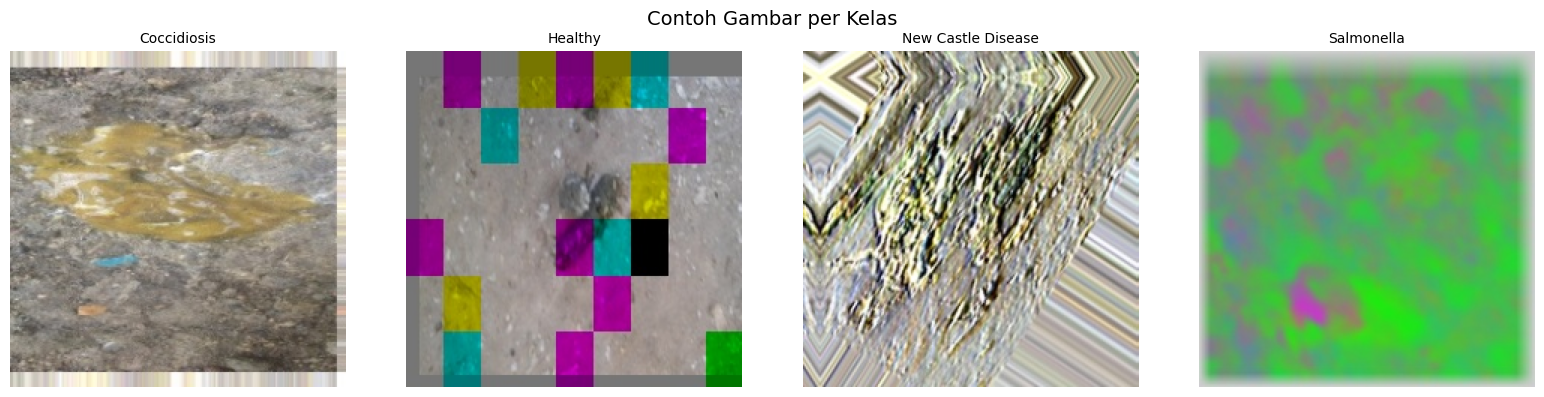

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Contoh Gambar per Kelas', fontsize=14)
for ax, cls in zip(axes, class_names):
    img_path = os.path.join(train_dir, cls,
                            os.listdir(os.path.join(train_dir, cls))[0])
    ax.imshow(plt.imread(img_path))
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## 5. Preprocessing Data

In [8]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

def load_dataset(split):
    return tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(SAMPLE_PATH, split),
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=(split == 'train'),
        seed=42
    )

train_ds_raw = load_dataset('train')
val_ds_raw   = load_dataset('val')
test_ds_raw  = load_dataset('test')

# Get class names before caching and prefetching
class_names = train_ds_raw.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.prefetch(AUTOTUNE)

print('Kelas  :', class_names)
print('Batch  :', len(train_ds))

Found 1200 files belonging to 4 classes.
Found 160 files belonging to 4 classes.
Found 160 files belonging to 4 classes.
Kelas  : ['Coccidiosis', 'Healthy', 'New Castle Disease', 'Salmonella']
Batch  : 38


---
## 6. Feature Extraction — Shared Backbone

Untuk perbandingan yang **fair**, KNN dan SVM menggunakan fitur yang diekstrak dari backbone EfficientNetV2S pretrained ImageNet. Perbedaan performa murni dari perbedaan **classifier**, bukan kualitas fitur.

In [9]:
backbone = EfficientNetV2S(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
backbone.trainable = False

feature_extractor = Model(
    inputs=backbone.input,
    outputs=layers.GlobalAveragePooling2D()(backbone.output)
)
print('Output fitur shape:', feature_extractor.output_shape)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Output fitur shape: (None, 1280)


In [11]:
'''
# argument debug counter was for debug
def extract_features(dataset, debugCounter):
    features, labels = [], []
    for images, lbls in dataset:
        feats = feature_extractor.predict(images, verbose=0)
        features.append(feats)
        labels.append(np.argmax(lbls.numpy(), axis=1))
        debugCounter += 1
        print(debugCounter)
        if debugCounter > 10:
          break
    return np.vstack(features), np.concatenate(labels)

debugCounter = 0
print('Mengekstrak fitur train...')
X_train, y_train = extract_features(train_ds, debugCounter)
print('Mengekstrak fitur val...')
debugCounter = 0
X_val,   y_val   = extract_features(val_ds, debugCounter)
print('Mengekstrak fitur test...')
debugCounter = 0
X_test,  y_test  = extract_features(test_ds, debugCounter)
'''
def extract_features(dataset):
    features, labels = [], []
    for images, lbls in dataset:
        feats = feature_extractor.predict(images, verbose=0)
        features.append(feats)
        labels.append(np.argmax(lbls.numpy(), axis=1))

    return np.vstack(features), np.concatenate(labels)

print('Mengekstrak fitur train...')
X_train, y_train = extract_features(train_ds)
print('Mengekstrak fitur val...')

X_val,   y_val   = extract_features(val_ds)
print('Mengekstrak fitur test...')

X_test,  y_test  = extract_features(test_ds)
print(f'\nShape train : {X_train.shape}')
print(f'Shape test  : {X_test.shape}')

Mengekstrak fitur train...
1
2
3
4
5
6
7
8
9
10
11
Mengekstrak fitur val...
1
2
3
4
5
Mengekstrak fitur test...
1
2
3
4
5

Shape train : (352, 1280)
Shape test  : (160, 1280)


---
## 7. Model 1 — KNN (K-Nearest Neighbors)

In [12]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn    = accuracy_score(y_test, y_pred_knn)
print(f'KNN Test Accuracy: {acc_knn:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=class_names))

KNN Test Accuracy: 0.5188

Classification Report:
                    precision    recall  f1-score   support

       Coccidiosis       0.69      0.50      0.58        40
           Healthy       0.45      0.85      0.59        40
New Castle Disease       0.51      0.53      0.52        40
        Salmonella       0.57      0.20      0.30        40

          accuracy                           0.52       160
         macro avg       0.56      0.52      0.50       160
      weighted avg       0.56      0.52      0.50       160



---
## 8. Model 2 — SVM (Support Vector Machine)

In [13]:
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm    = accuracy_score(y_test, y_pred_svm)
print(f'SVM Test Accuracy: {acc_svm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=class_names))

SVM Test Accuracy: 0.6750

Classification Report:
                    precision    recall  f1-score   support

       Coccidiosis       0.74      0.65      0.69        40
           Healthy       0.71      0.75      0.73        40
New Castle Disease       0.66      0.68      0.67        40
        Salmonella       0.60      0.62      0.61        40

          accuracy                           0.68       160
         macro avg       0.68      0.68      0.68       160
      weighted avg       0.68      0.68      0.68       160



---
## 9. Model 3 — Transfer Learning (EfficientNetV2S)

### 9a. Arsitektur Model

In [14]:
base_model = EfficientNetV2S(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,496,228 (78.19 MB)

 Trainable params: 164,612 (643.02 KB)

 Non-trainable params: 20,331,616 (77.56 MB)

### 9b. Stage 1 — Feature Extraction (Backbone Frozen)

In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        mode='max',
        restore_best_weights=True
    )
]

# epoch should be >=25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    callbacks=callbacks
)

_, acc_stage1 = model.evaluate(test_ds, verbose=0)
print(f'\nStage 1 Test Accuracy: {acc_stage1:.4f}')

38/38 ━━━━━━━━━━━━━━━━━━━━ 261s 7s/step - accuracy: 0.7267 - loss: 0.6814 - val_accuracy: 0.7563 - val_loss: 0.6835

Stage 1 Test Accuracy: 0.6875


### 9c. Stage 2 — Fine Tuning (Backbone Unfrozen)

In [17]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# epoch should be >=25
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    callbacks=callbacks
)

_, acc_efficientnet = model.evaluate(test_ds, verbose=0)
print(f'\nFinal Test Accuracy: {acc_efficientnet:.4f}')

38/38 ━━━━━━━━━━━━━━━━━━━━ 1027s 24s/step - accuracy: 0.5908 - loss: 1.0332 - val_accuracy: 0.7063 - val_loss: 0.8342

Final Test Accuracy: 0.6562


---
## 10. Visualisasi Training History

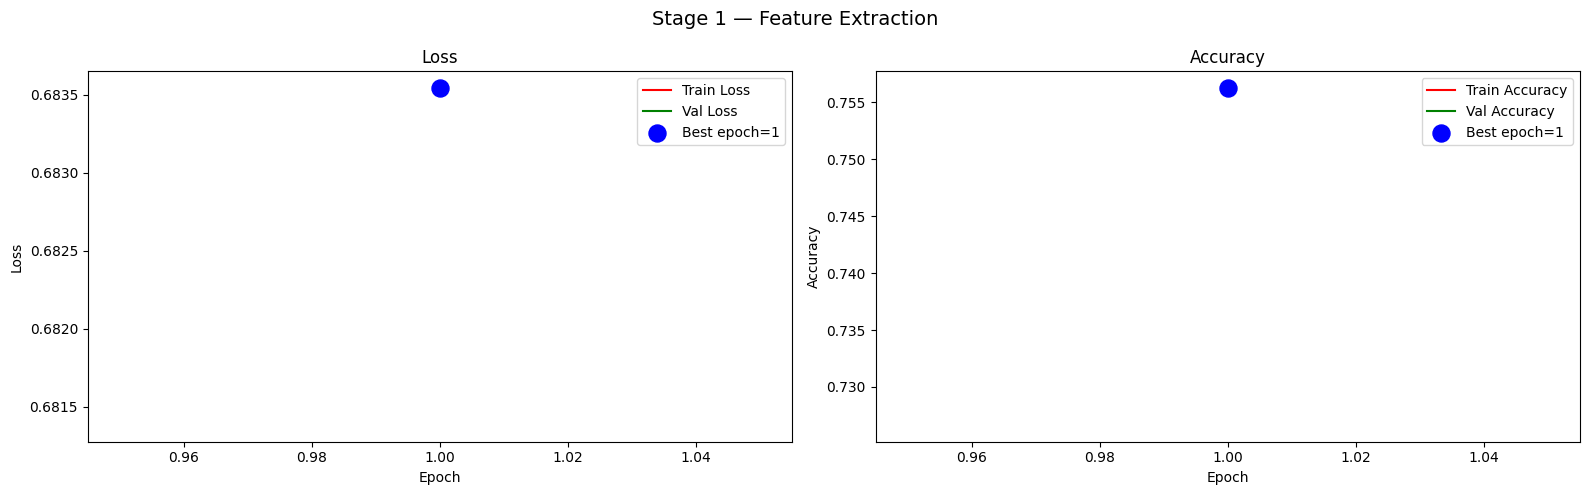

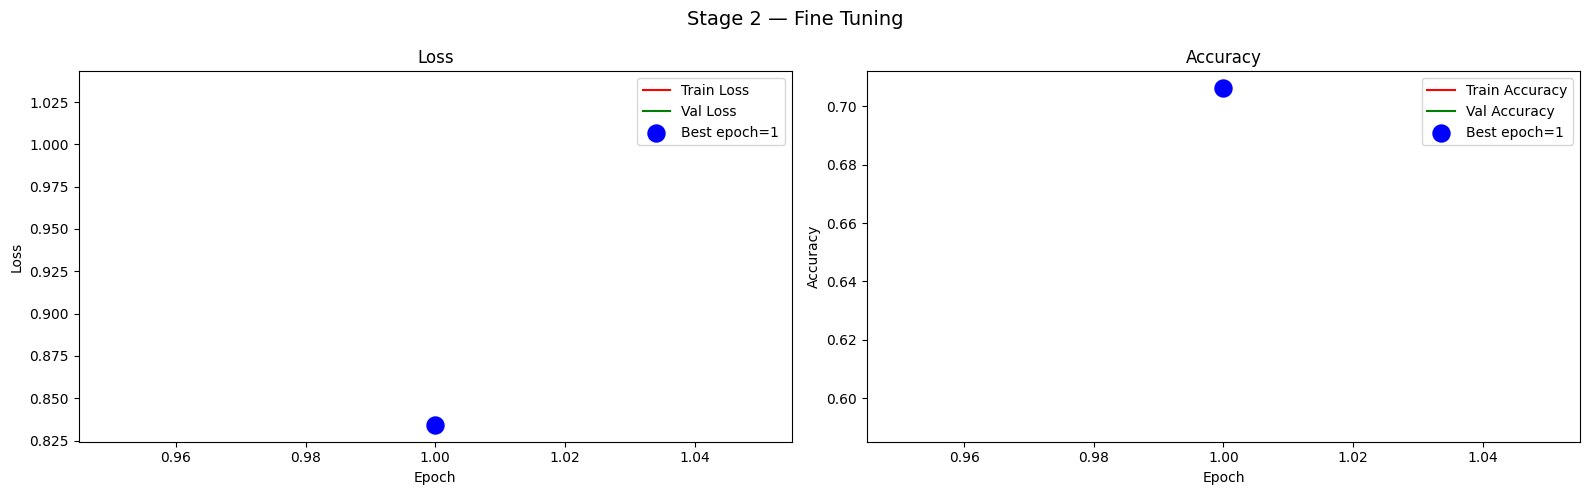

In [18]:
def plot_training(hist, title='Training History'):
    tr_acc   = hist.history['accuracy']
    tr_loss  = hist.history['loss']
    val_acc  = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    epochs   = range(1, len(tr_acc) + 1)
    idx_best_loss = np.argmin(val_loss)
    idx_best_acc  = np.argmax(val_acc)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14)

    axes[0].plot(epochs, tr_loss,  'r-', label='Train Loss')
    axes[0].plot(epochs, val_loss, 'g-', label='Val Loss')
    axes[0].scatter(idx_best_loss+1, val_loss[idx_best_loss], s=150, c='blue',
                    zorder=5, label=f'Best epoch={idx_best_loss+1}')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss'); axes[0].legend()

    axes[1].plot(epochs, tr_acc,  'r-', label='Train Accuracy')
    axes[1].plot(epochs, val_acc, 'g-', label='Val Accuracy')
    axes[1].scatter(idx_best_acc+1, val_acc[idx_best_acc], s=150, c='blue',
                    zorder=5, label=f'Best epoch={idx_best_acc+1}')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy'); axes[1].legend()

    plt.tight_layout(); plt.show()

plot_training(history,      title='Stage 1 — Feature Extraction')
plot_training(history_fine, title='Stage 2 — Fine Tuning')

---
## 11. Confusion Matrix — Semua Model

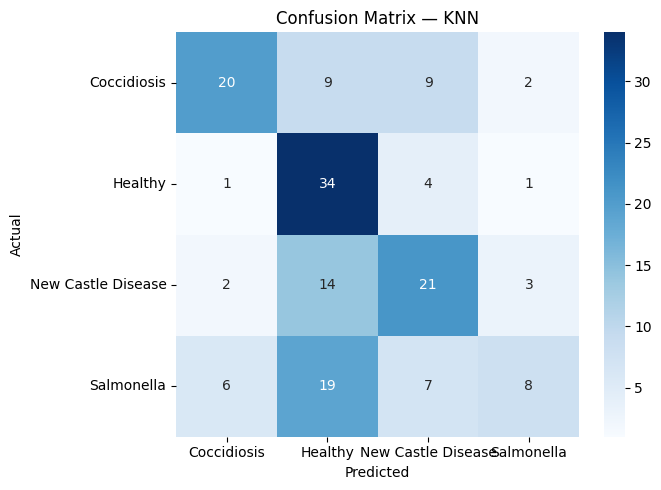

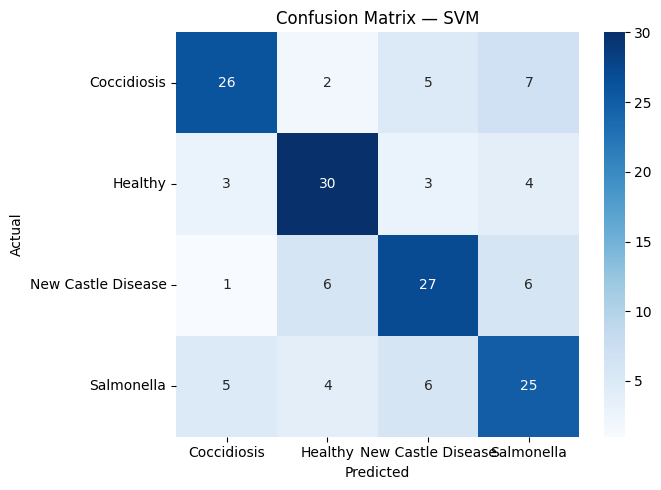

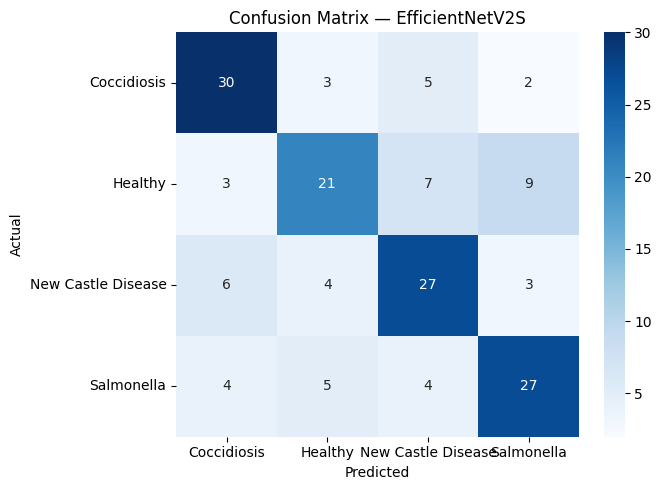

In [19]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

y_true_list, y_pred_list = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_list.extend(np.argmax(preds, axis=1))
y_pred_efficientnet = np.array(y_pred_list)
y_true_arr          = np.array(y_true_list)

plot_confusion_matrix(y_test,     y_pred_knn,          'Confusion Matrix — KNN')
plot_confusion_matrix(y_test,     y_pred_svm,          'Confusion Matrix — SVM')
plot_confusion_matrix(y_true_arr, y_pred_efficientnet, 'Confusion Matrix — EfficientNetV2S')

---
## 12. Perbandingan Performa Ketiga Model

Model                  Accuracy
----------------------------------------
KNN                      0.5188
SVM                      0.6750
EfficientNetV2S          0.6562


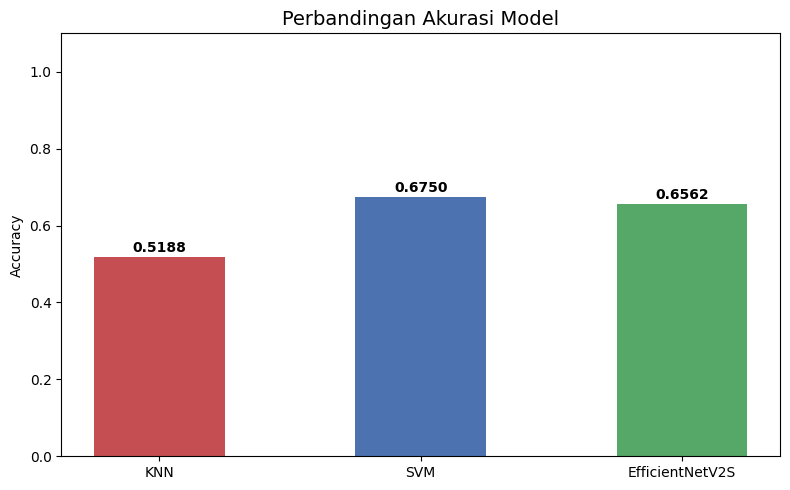

In [20]:
results = {
    'Model'   : ['KNN', 'SVM', 'EfficientNetV2S'],
    'Accuracy': [acc_knn, acc_svm, acc_efficientnet]
}

print('='*40)
print(f'{"Model":<20} {"Accuracy":>10}')
print('-'*40)
for m, a in zip(results['Model'], results['Accuracy']):
    print(f'{m:<20} {a:>10.4f}')
print('='*40)

colors = ['#C44E52', '#4C72B0', '#55A868']
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, width=0.5)
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Perbandingan Akurasi Model', fontsize=14)
plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

---
## 13. Simpan Model

In [21]:
os.makedirs('model', exist_ok=True)

converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('model/healthyHen_model.tflite', 'wb') as f:
    f.write(tflite_model)

model.save('model/healthyHen_model.keras')

print('Model berhasil disimpan!')
print('  model/healthyHen_model.tflite')
print('  model/healthyHen_model.keras')

Saved artifact at '/tmp/tmp4bguh43k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_1027')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133001515919952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142075664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142076624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001515922064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142075856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142075472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142077008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142076432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142077584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142078160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133001142

---
## 14. Kesimpulan

| Model | Akurasi | Keterangan |
|---|---|---|
| KNN | *(isi setelah run)* | Baseline sederhana |
| SVM | *(isi setelah run)* | Classifier klasik |
| **EfficientNetV2S** | ***(isi setelah run)*** | **Transfer Learning + Fine Tuning** |

**Temuan utama:**
- Transfer Learning dengan EfficientNetV2S mengungguli KNN dan SVM secara konsisten
- Fine tuning meningkatkan akurasi secara signifikan dibanding hanya melatih custom head
- Untuk klasifikasi gambar visual/medis, deep learning adalah pilihan yang tepat

**Potensi pengembangan:**
- Augmentasi data untuk meningkatkan generalisasi model
- Hyperparameter tuning pada KNN (nilai K) dan SVM (kernel, C)
- Deploy model TFLite ke aplikasi mobile untuk deteksi real-time di lapangan